<a href="https://colab.research.google.com/github/DANDIBHOTLA/24EU01077-Machine-Learning/blob/main/Post_lab_8_and_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

# Encode Sex
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Create ANN model
ann_titanic = Sequential([
    Dense(16, activation='relu', input_shape=(6,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
ann_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nANN Architecture:")
ann_titanic.summary()

# Train model
history_titanic = ann_titanic.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Evaluate model
test_loss, test_accuracy = ann_titanic.evaluate(X_test, y_test, verbose=0)

print("\nTitanic ANN Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Training set shape: (712, 6)
Test set shape: (179, 6)

ANN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5466 - loss: 0.6941 - val_accuracy: 0.5524 - val_loss: 0.6669
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6011 - loss: 0.6360 - val_accuracy: 0.6084 - val_loss: 0.6248
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6432 - loss: 0.5925 - val_accuracy: 0.6154 - val_loss: 0.5941
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6714 - loss: 0.5624 - val_accuracy: 0.6503 - val_loss: 0.5730
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7118 - loss: 0.5390 - val_accuracy: 0.7483 - val_loss: 0.5587
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7645 - loss: 0.5221 - val_accuracy: 0.7832 - val_loss: 0.5440
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7926 - loss: 0.5059 - val_accuracy: 0.8042 - val_loss: 0.5308
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8032 - loss: 0.4903 - val_accuracy: 0.8042 - v

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.86      0.84       110
    Survived       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



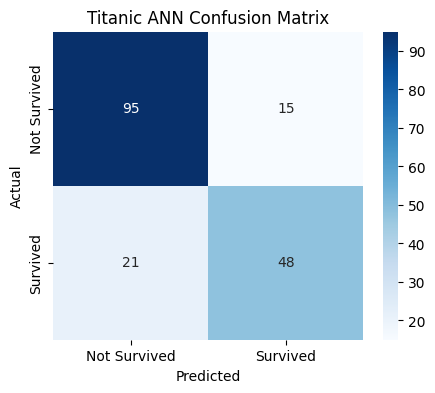

In [2]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (ann_titanic.predict(X_test) >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Survived', 'Survived']
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic ANN Confusion Matrix")
plt.show()

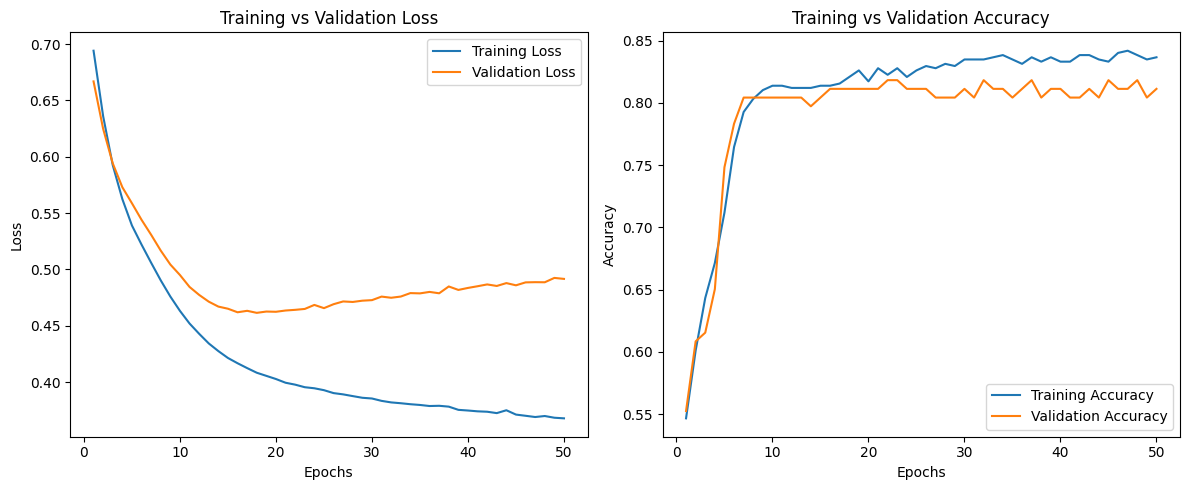

In [3]:
import matplotlib.pyplot as plt

h = history_titanic.history
epochs = range(1, len(h['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, h['loss'], label='Training Loss')
plt.plot(epochs, h['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, h['accuracy'], label='Training Accuracy')
plt.plot(epochs, h['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

WEEK  7 POSTLAB


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

# Encode Sex
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Create Random Forest model
model = RandomForestClassifier(random_state=42)

# ---------------- K-FOLD CROSS VALIDATION ----------------

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print("K-Fold Cross Validation Scores:")
print(scores)

print("\nMean K-Fold Accuracy:", scores.mean())

# ---------------- GRID SEARCH ----------------

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# ---------------- TEST SET ----------------

best_model = grid_search.best_estimator_

test_accuracy = best_model.score(X_test, y_test)

print("\nTest Accuracy:")
print(test_accuracy)

K-Fold Cross Validation Scores:
[0.81818182 0.8041958  0.79577465 0.80985915 0.82394366]

Mean K-Fold Accuracy: 0.8103910174332711

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.8343149807938541

Test Accuracy:
0.8156424581005587
